# Compressing Data vis Dimensionality Reduction
- PCA (Principal Component Analysis)
- LDA (Linear Discriminant Analysis)

Both PCA and LDA are linear transformation techinques that can be used to reduce the number of dimensions in a dataset; the former is an unsupervised algorithm, whereas the latter is supervised.

## Part 1: PCA - Principle Component Analysis
#### Steps
- Standardize the d-dimensional dataset
- Construct the convariance matrix
- Decompose the covariance matrix into its eigenvectors and eigenvalues
- Sort the eigenvalues by decresing order to rank the corresponding eigenvectors
- Select k eigenvectors, which correspond to the k largest eigenvalues, where k ist eh diemnsionality of the new feature subspace (k<=d)
- Construct a projection matrix, W, from the top k eigenvectors.
- Transform the d-dimensional input dataset, X, using the projection matrix, W, to obtain the new k-dimensional feature subspace.


### 1) Example
### Import packages and load data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
df_wine = pd.read_csv('https://archive.ics.uci.edu/ml/'
           'machine-learning-databases/wine/wine.data',
           header=None)

In [3]:
df_wine.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [4]:
# split data to train and test
X, y = df_wine.iloc[:,1:].values, df_wine.iloc[:,0].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)

# Standardize the feature
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

### Calculate Eigenvalues & Eigenvectors

Covariance
- A positive covariance between features indicates that the features increase or decrease together, whereas a negative covariance indicates that the features vary in opposite directions.

Eigenvalues & Eigenvectors
- Eigenvectors (principal components) that contains most of the information (variance). 
- Eigenvalues define the magnitude of the eigenvectors



In [5]:
# calcualte the covariance amtrix
cov_mat = np.cov(X_train_std.T)

# calcualte the eigenvalues and eigenvectors
eigen_vals, eigen_vecs = np.linalg.eig(cov_mat)

In [6]:
print(eigen_vals)

[4.84274532 2.41602459 1.54845825 0.96120438 0.84166161 0.6620634
 0.51828472 0.34650377 0.3131368  0.10754642 0.21357215 0.15362835
 0.1808613 ]


In [7]:
eigen_vecs.shape

(13, 13)

`Review top Eigenvalues`

[]

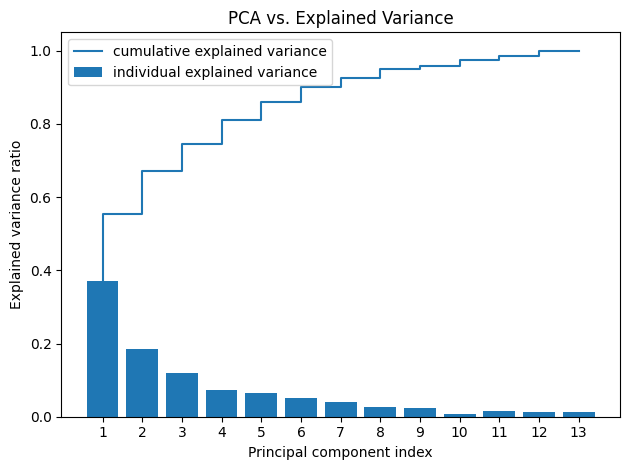

In [8]:
eigen_pct = eigen_vals / np.sum(eigen_vals)
cum_eigen_pct = np.cumsum(eigen_pct)

plt.bar(np.arange(1, len(eigen_pct)+1), eigen_pct, label='individual explained variance')
plt.step(np.arange(1, len(eigen_pct)+1), cum_eigen_pct, label='cumulative explained variance')
plt.xlabel('Principal component index')
plt.ylabel('Explained variance ratio')
plt.title('PCA vs. Explained Variance')
plt.xticks(np.arange(1,14))
plt.legend(loc='best')
plt.tight_layout()
plt.plot()

In [9]:
np.arange(len(eigen_pct))

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [10]:
eigen_pct

array([0.36951469, 0.18434927, 0.11815159, 0.07334252, 0.06422108,
       0.05051724, 0.03954654, 0.02643918, 0.02389319, 0.00820609,
       0.01629614, 0.01172226, 0.01380021])

In [11]:
eigen_vals

array([4.84274532, 2.41602459, 1.54845825, 0.96120438, 0.84166161,
       0.6620634 , 0.51828472, 0.34650377, 0.3131368 , 0.10754642,
       0.21357215, 0.15362835, 0.1808613 ])

### Feature transformation
- Select k eigenvectos, which correspond to the k largest eigenvalues, where k is the dimensionality of the new feature subspace (k<= d)
- Construct a projection matrix, W, from the 'top' k eigenvectors
- Transform the d-dimensional input dataset, X, using th eprojection matrix, W, to obtain the new k-dimensional feature subspace

In [12]:
pd.DataFrame(eigen_vecs)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,-0.137242,0.503035,0.137749,0.003296,0.290625,-0.299097,-0.079053,0.368176,0.398377,-0.094487,0.374639,-0.127835,0.262834
1,0.247243,0.164871,-0.096150,-0.562647,-0.089538,-0.627036,0.274002,0.012578,-0.110458,0.026365,-0.137406,0.080640,-0.266769
2,-0.025452,0.244565,-0.677776,0.108977,0.160835,-0.000389,-0.132328,-0.177578,-0.382497,0.142748,0.461583,0.016792,-0.115543
3,0.206945,-0.113529,-0.625041,-0.033819,-0.051587,0.040584,-0.223999,0.440592,0.243374,-0.130486,-0.418954,-0.110846,0.199483
4,-0.154366,0.289745,-0.196135,0.367511,-0.676487,-0.065777,0.405269,-0.116618,0.258982,-0.067608,0.010047,0.079388,0.028902
5,-0.393770,0.050801,-0.140311,-0.240245,0.118511,0.058978,0.034742,-0.350192,0.342313,0.459918,-0.221254,-0.491459,-0.066387
6,-0.417351,-0.022873,-0.117054,-0.187053,0.107100,0.030110,-0.041784,-0.218718,0.036123,-0.814584,-0.041751,-0.050307,-0.213349
7,0.305729,0.090489,-0.131218,0.022926,0.507582,0.271728,0.631146,-0.197129,0.171437,-0.095748,-0.088757,0.175328,0.186391
8,-0.306683,0.008352,-0.030431,-0.496262,-0.201635,0.439998,0.323123,0.433056,-0.244370,0.067247,0.199922,-0.003676,0.168083
9,0.075541,0.549776,0.079930,-0.106483,-0.005736,0.411743,-0.269083,0.066841,0.155515,0.087334,-0.221669,0.359757,-0.466369


In [13]:
# create DataFrame with value as eigen_vecs, column as eigen_vals, the sort from high to low eigen_vals (pick top 2)
W = pd.DataFrame(eigen_vecs, columns=eigen_vals).sort_index(axis=1, ascending=False).iloc[:,:2].values

In [14]:
W

array([[-0.13724218,  0.50303478],
       [ 0.24724326,  0.16487119],
       [-0.02545159,  0.24456476],
       [ 0.20694508, -0.11352904],
       [-0.15436582,  0.28974518],
       [-0.39376952,  0.05080104],
       [-0.41735106, -0.02287338],
       [ 0.30572896,  0.09048885],
       [-0.30668347,  0.00835233],
       [ 0.07554066,  0.54977581],
       [-0.32613263, -0.20716433],
       [-0.36861022, -0.24902536],
       [-0.29669651,  0.38022942]])

In [15]:
X_train_std[0]

array([ 0.71225893,  2.22048673, -0.13025864,  0.05962872, -0.50432733,
       -0.52831584, -1.24000033,  0.84118003, -1.05215112, -0.29218864,
       -0.20017028, -0.82164144, -0.62946362])

`Transform training dataset onto the two principal components - by calculating the matrix dot product`
- dot product is actually project from one array to component

In [16]:
# example of first two columns project to top two principle components
X_train_std[0].dot(W)

array([2.38299011, 0.45458499])

In [17]:
# apply to all train data
X_train_pcs = X_train_std.dot(W)

In [18]:
X_train_pcs[:5]

array([[ 2.38299011,  0.45458499],
       [-1.96578183,  1.65376939],
       [-2.53907598,  1.02909066],
       [-1.43010776,  0.6024011 ],
       [ 3.14147227,  0.66214979]])

`Review the two dimensional data`
- we can see the princpal component 1 is more spread along the x-axis than the principal component along the y-axis. 

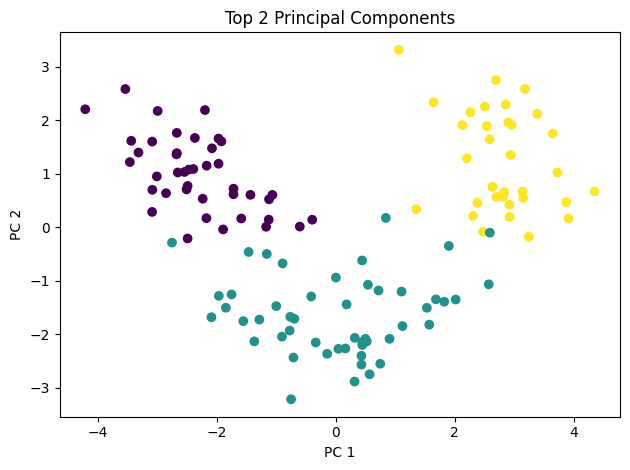

In [19]:
plt.scatter(X_train_pcs[:,0], X_train_pcs[:,1], c=y_train)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title('Top 2 Principal Components')
plt.tight_layout()
plt.show()

## 2) Principal Component Analsyis in scikit-learn
- PCA class is another one of scikit-learn's transformer classes, where we first fit the model using the training data before we transform both the training data and the test dataset using the same model parameters.

In [20]:
from mlxtend.plotting import plot_decision_regions
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

In [21]:
# initialize PCA and the model
pca = PCA(n_components=2)
lr = LogisticRegression(
    random_state=1,
    solver='lbfgs'
)

X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

# train the model
lr.fit(X_train_pca, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

<Axes: >

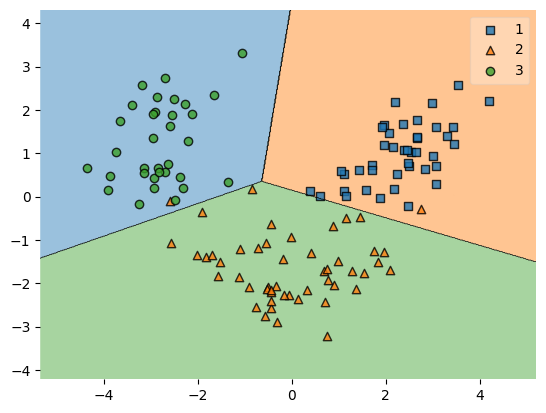

In [22]:
# show the boundaries
plot_decision_regions(X_train_pca, y_train, clf=lr)

`Check the explained variance ratios`

In [23]:
pca = PCA(n_components=None) # set n_components = None, it would return all principal components in a sorted order
X_train_pca = pca.fit_transform(X_train_std)
pca.explained_variance_ratio_

array([0.36951469, 0.18434927, 0.11815159, 0.07334252, 0.06422108,
       0.05051724, 0.03954654, 0.02643918, 0.02389319, 0.01629614,
       0.01380021, 0.01172226, 0.00820609])

## Part 2: Principal component analysis versus linear discriminant analysis

**Plan:**
*   Standardize the d-dimensional dataset (d is the number of features).
*   For each class, compute the d-dimensional mean vector.
*   Construct the between-class scatter matrix, $S_B$, and the within-class scatter matrix, $S_W$.
*   Compute the eigenvectors and corresponding eigenvalues of the matrix, $\mathbf{S}_W^{-1} \mathbf{S}_B$.
*   Sort the eigenvalues by decreasing order to rank the corresponding eigenvectors.
*   Choose the k eigenvectors that correspond to the k largest eigenvalues to construct a $d \times k$-dimensional transformation matrix, $\mathbf{W}$; the eigenvectors are the columns of this matrix.
*   Project the examples onto the new feature subspace using the transformation matrix, $\mathbf{W}$.

`d-dimensional mean vector`
- means for each feature within the same class

In [24]:
mean_vecs = []
for label in range(1,4):
    mean_vecs.append(np.mean(X_train_std[y_train==label], axis=0))

In [25]:
mean_vecs

[array([ 0.9065826 , -0.34973457,  0.32010329, -0.71891449,  0.50558678,
         0.88069702,  0.95894709, -0.55161049,  0.54159322,  0.23383109,
         0.58971299,  0.65631399,  1.20749382]),
 array([-0.87487963, -0.28480003, -0.37347228,  0.31571225, -0.38480347,
        -0.04332505,  0.06345321, -0.09460613,  0.07034749, -0.82860474,
         0.31436962,  0.36084258, -0.72528643]),
 array([ 0.199215  ,  0.8660339 ,  0.168163  ,  0.41484489, -0.04511771,
        -1.02855532, -1.28756034,  0.82867687, -0.77947565,  0.96494432,
        -1.20899133, -1.36215159, -0.40130076])]

In [26]:
mean_vecs[0].shape

(13,)

`Construct the between-class scatter matrix adn within-class scatter matrix`
- scatter matrix: it captures this relationship but often focues on the raw sum of squared differences.

`1 - Within class scatter matrix`

Below assump the samples has equal count of classes

In [46]:
d = 13 # number of features
s_w = np.zeros((13, 13))
for label, mv in zip(range(1, 4), mean_vecs):
    class_scatter = np.zeros((d,d)) # same class scatter
    for row in X_train_std[y_train == label]:
        row, mv = row.reshape(d,1), mv.reshape(d,1)
        class_scatter += (row - mv).dot((row - mv).T) 
    s_w += class_scatter # aggregate all different classes scatter together    
print(f'Within-class scatter matrix {s_w.shape}')

Within-class scatter matrix (13, 13)


In [47]:
# we can see the classes are not equal
np.bincount(y_train)[1:]

array([41, 50, 33])

we will use covariance matrix

In [48]:
d = 13 # number of features
s_w = np.zeros((13, 13))
for label, mv in zip(range(1, 4), mean_vecs):
    class_scatter = np.cov(X_train_std[y_train==label].T)
    s_w += class_scatter
print(f'Scaled within-class scatter matrix {s_w.shape}')

Scaled within-class scatter matrix (13, 13)


`2 - Between class scatter matrix`

In [49]:
mean_overall = np.mean(X_train_std, axis=0) # just 1-dimension
d =13 # number of features
s_b = np.zeros((d,d))

for i, mean_vec in enumerate(mean_vecs):
    n = X_train_std[y_train == 0 + 1, :].shape[0] # total samples per class
    mean_vec = mean_vec.reshape(d, 1) # convert to column-wise  (make sure the final size is (d,d))
    mean_overall = mean_overall.reshape(d,1) # convert to coumn-wise (make sure the final size is (d,d))

    s_b += n * (mean_vec - mean_overall).dot((mean_vec - mean_overall).T) # weighted by sample size of each class 'n'

print(f'Between-class scatter matrix: {s_b.shape}')

Between-class scatter matrix: (13, 13)


`Selecting linear discriminants for the new feature subspace`

In [50]:
# calculate the eigenvalues, and eigenvectors
eigen_vals, eigen_vecs = np.linalg.eig(np.linalg.inv(s_w).dot(s_b))

In [51]:
# create DataFrame with value as eigen_vecs, column as eigen_vals, the sort from high to low eigen_vals (pick top 2)
W = pd.DataFrame(eigen_vecs, columns=eigen_vals).sort_index(axis=1, ascending=False).iloc[:,:]

There are only two nonzero eigenvalues, because the number of linear discriminants is at most c-1, where c is the number of class labels.

In [71]:
np.sort(eigen_vals.real)[::-1]

array([ 3.97532675e+02,  1.60456228e+02,  2.92000839e-14,  2.92000839e-14,
        2.84217094e-14,  1.47895637e-14,  1.47895637e-14,  3.48252919e-15,
       -2.95502348e-15, -2.95502348e-15, -6.77472981e-15, -1.85186750e-14,
       -3.84722007e-14])

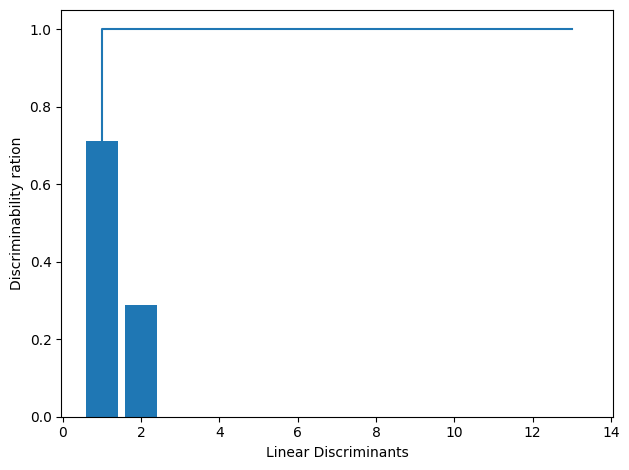

In [80]:
# below show the useful information after the LDA
plt.bar(range(1, len(eigen_vals)+1), (np.sort(eigen_vals.real)[::-1] / np.sort(eigen_vals.real)[::-1].sum()))
plt.step(range(1, len(eigen_vals)+1), (np.sort(eigen_vals.real)[::-1] / np.sort(eigen_vals.real)[::-1].sum()).cumsum())
plt.xlabel('Linear Discriminants')
plt.ylabel('Discriminability ration')
plt.tight_layout()
plt.show()

In [84]:
W.iloc[:,:2].values

array([[-0.12290282+0.j, -0.41933995+0.j],
       [ 0.10089187+0.j, -0.14575857+0.j],
       [ 0.00530062+0.j, -0.35059121+0.j],
       [ 0.12865723+0.j,  0.33371047+0.j],
       [-0.0112811 +0.j, -0.08230282+0.j],
       [ 0.1865844 +0.j,  0.10348605+0.j],
       [-0.75352901+0.j,  0.19993132+0.j],
       [-0.07459794+0.j, -0.01804034+0.j],
       [-0.00381708+0.j,  0.08958807+0.j],
       [ 0.30833027+0.j, -0.18078638+0.j],
       [-0.05010725+0.j,  0.26737991+0.j],
       [-0.35490008+0.j, -0.05020566+0.j],
       [-0.35535363+0.j, -0.62938709+0.j]])

#### Projecting examples onto the new features space

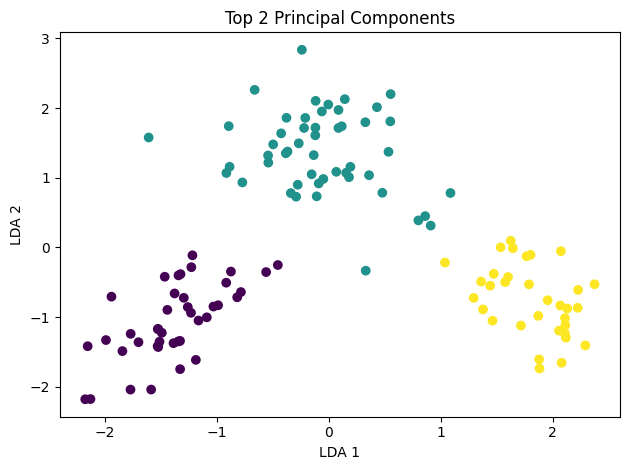

In [89]:
X_train_lda = X_train_std.dot(W.iloc[:,:2].values)
plt.scatter(X_train_lda[:,0], X_train_lda[:,1], c=y_train)
plt.xlabel('LDA 1')
plt.ylabel('LDA 2')
plt.title('Top 2 Principal Components')
plt.tight_layout()
plt.show()

### LDA via scikit-learn

In [90]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
lda = LDA(n_components=2)
X_train_lda = lda.fit_transform(X_train_std, y_train)

In [91]:
lr = LogisticRegression(solver='lbfgs', random_state=1)
lr.fit(X_train_lda, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

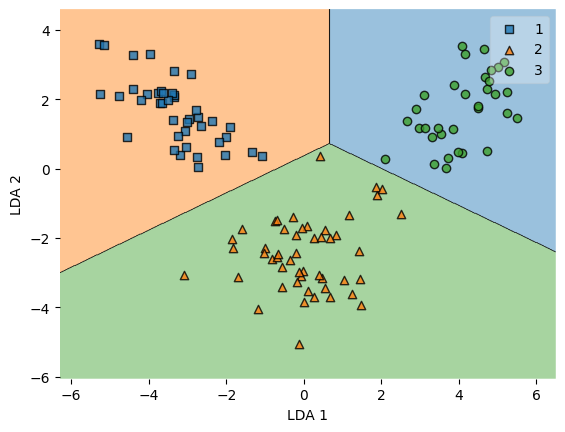

In [94]:
plot_decision_regions(X_train_lda, y_train, clf=lr)
plt.xlabel('LDA 1')
plt.ylabel('LDA 2')
plt.show()

## Using kernel principal component analysis for nonlinear mappings

## Kernel

In Machine Learning, the term **"Kernel"** has a completely different meaning than it does in operating systems.

In machine learning, a kernel is a **mathematical function** used to transform data into a higher-dimensional space. It is most commonly associated with the **Kernel Trick**, which is used to solve non-linear problems using linear methods.

Here is a detailed breakdown:

---

### 1. The Core Problem: Non-Linearity
Imagine you have a dataset consisting of red dots in the center and blue dots forming a ring around them. You cannot draw a single **straight line** (a linear separator) to separate the red dots from the blue dots. This is a "non-linear" problem.

To solve this, you need to move the data into a **higher dimension**. If you "lift" those dots into 3D space (adding a Z-axis), you could suddenly pass a flat sheet (a plane) between the red and blue points.

### 

### 2. The "Kernel Trick"
Calculating the coordinates of every single data point in a high-dimensional space is mathematically "expensive"—it requires massive amounts of computing power and memory.

The **Kernel Trick** is a mathematical shortcut. It allows us to calculate the relationship (the dot product) between two points in a high-dimensional space **without actually performing the transformation**. 

In simple terms: The kernel function gives you the result as if you had moved to a higher dimension, but it does all the math in the original, lower-dimensional space. This makes complex algorithms incredibly fast and efficient.

### 3. Common Types of Kernels
Different kernels are used depending on the shape and complexity of the data:

*   **Linear Kernel:** The simplest form. It assumes the data is already linearly separable (can be split by a straight line). It is very fast but only works for simple patterns.
*   **Polynomial Kernel:** Represents the similarity of vectors in a feature space over polynomials of the original variables. It can model more complex, curved boundaries.
*   **Radial Basis Function (RBF) / Gaussian Kernel:** The most popular kernel. It can handle extremely complex, overlapping data by creating "bubbles" around data points. It essentially maps data into an infinite-dimensional space.
*   **Sigmoid Kernel:** Derived from neural network theory; it acts similarly to the activation functions used in deep learning.

### 4. Where is this used?
The most famous application of kernels is in **Support Vector Machines (SVM)**. SVMs use kernels to find the "maximum margin hyperplane" that separates different classes of data, even when those classes are tangled together in complex shapes.

Kernels are also used in:
*   **Principal Component Analysis (PCA):** Known as Kernel PCA, used for non-linear dimensionality reduction.
*   **Kernel Density Estimation (KDE):** Used to estimate the probability density function of a random variable.

### Summary Comparison

| Feature | OS Kernel | ML Kernel |
| :--- | :--- | :--- |
| **Nature** | Software/Code | Mathematical Function |
| **Purpose** | Manages hardware & software | Transforms data dimensions |
| **Goal** | Resource management & security | Finding patterns in non-linear data |
| **Key Concept** | Interface between CPU and App | The "Kernel Trick" (shortcut math) |

**What is kernel trick:**
- We perform a nonlinear mapping via KPCA that transforms the data onto a higher-dimensional space. We then use standard PCA in this higher-dimensional space to project the data back onto a lower-dimensional space where the examples can be separated by a linear classifier. However, one downside of this approach is that it is computationally very expensive, and this si where we use the **kernel trick.**

- Using the kernel trick, we can compute the similarity between two high-dimension feature vectors in the original feature space.

**Most commonly used kernels**
- polynomial kernel
- hyperbolic tangent kernle
- radial basis function (RBF)

**`Example 1 - separating half-moon shapes`**

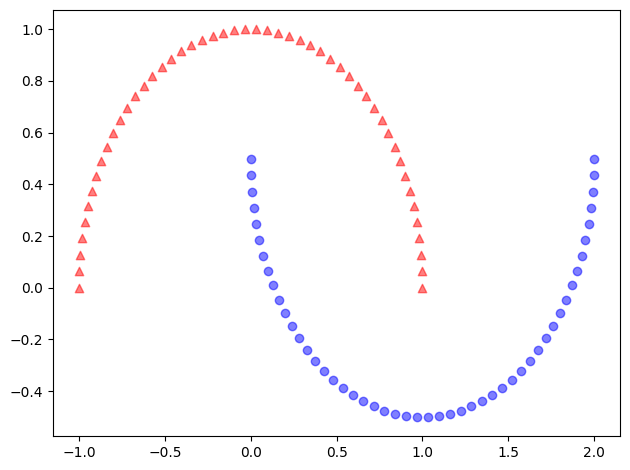

In [95]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=100, random_state=123)
plt.scatter(X[y==0, 0], X[y==0,1],
            color='red', marker='^', alpha=0.5)

plt.scatter(X[y==1,0], X[y==1, 1],
            color='blue', marker='o', alpha=0.5)
plt.tight_layout()
plt.show()

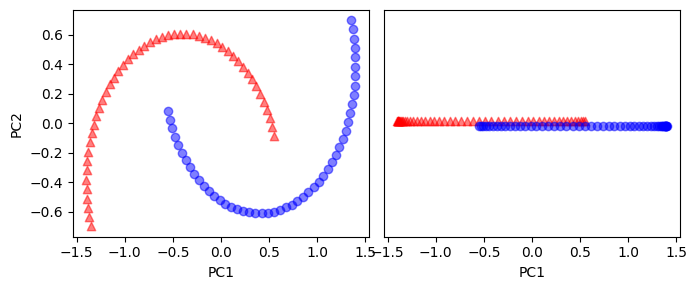

In [98]:
from sklearn.decomposition import PCA
scikit_pca = PCA(n_components=2)
X_spca = scikit_pca.fit_transform(X)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(7,3))
ax[0].scatter(X_spca[y==0, 0], X_spca[y==0, 1],
              color='red', marker='^', alpha=0.5)
ax[0].scatter(X_spca[y==1, 0], X_spca[y==1, 1],
              color='blue', marker='o', alpha=0.5)

ax[1].scatter(X_spca[y==0, 0], np.zeros((50,1)) + 0.02,
              color='red', marker='^', alpha=0.5)
ax[1].scatter(X_spca[y==1, 0], np.zeros((50,1))-0.02,
              color='blue', marker='o', alpha=0.5)
ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2')
ax[1].set_ylim([-1,1])
ax[1].set_yticks([])
ax[1].set_xlabel('PC1')
plt.tight_layout()
plt.show()

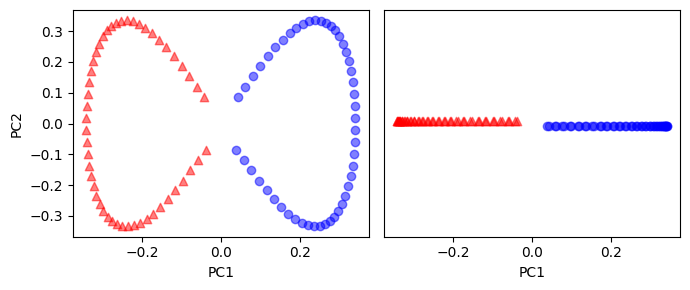

In [101]:
from sklearn.decomposition import KernelPCA
scikit_pca = KernelPCA(n_components=2, kernel='rbf', gamma=20) # low gamma means points far away as being 'similar'
X_spca = scikit_pca.fit_transform(X)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(7,3))
ax[0].scatter(X_spca[y==0, 0], X_spca[y==0, 1],
              color='red', marker='^', alpha=0.5)
ax[0].scatter(X_spca[y==1, 0], X_spca[y==1, 1],
              color='blue', marker='o', alpha=0.5)

ax[1].scatter(X_spca[y==0, 0], np.zeros((50,1)) + 0.02,
              color='red', marker='^', alpha=0.5)
ax[1].scatter(X_spca[y==1, 0], np.zeros((50,1))-0.02,
              color='blue', marker='o', alpha=0.5)
ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2')
ax[1].set_ylim([-1,1])
ax[1].set_yticks([])
ax[1].set_xlabel('PC1')
plt.tight_layout()
plt.show()

`Example 2 - separating concentric circles`

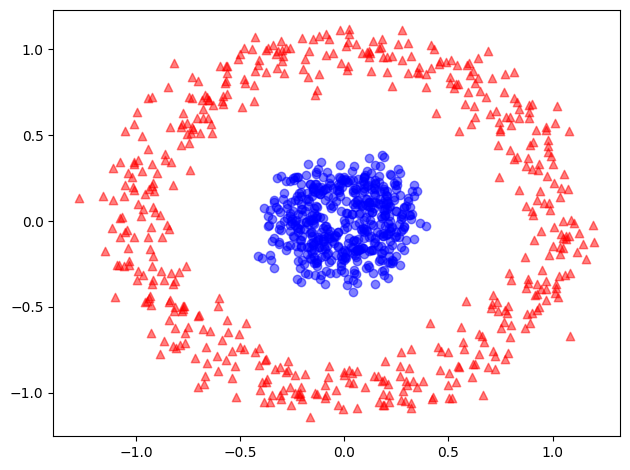

In [124]:
from sklearn.datasets import make_circles
X, y = make_circles(n_samples=1000,
                     random_state=123, noise=0.1,
                     factor=0.2)

plt.scatter(X[y == 0, 0], X[y == 0, 1],
             color='red', marker='^', alpha=0.5)
plt.scatter(X[y == 1, 0], X[y == 1, 1],
             color='blue', marker='o', alpha=0.5)
plt.tight_layout()
plt.show()

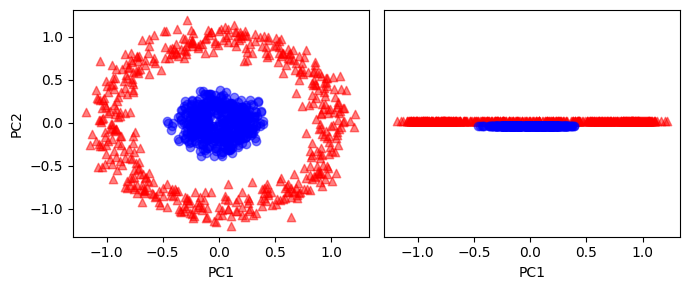

In [135]:
scikit_pca = PCA(n_components=2)
X_spca = scikit_pca.fit_transform(X)
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=(7,3))

ax[0].scatter(X_spca[y==0, 0], X_spca[y==0, 1],
               color='red', marker='^', alpha=0.5)
ax[0].scatter(X_spca[y==1, 0], X_spca[y==1, 1],
               color='blue', marker='o', alpha=0.5)

ax[1].scatter(X_spca[y==0, 0], np.zeros((500,1))+0.02,
               color='red', marker='^', alpha=0.5)
ax[1].scatter(X_spca[y==1, 0], np.zeros((500,1))-0.02,
               color='blue', marker='o', alpha=0.5)

ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2')
ax[1].set_ylim([-1, 1])
ax[1].set_yticks([])
ax[1].set_xlabel('PC1')
plt.tight_layout()
plt.show()

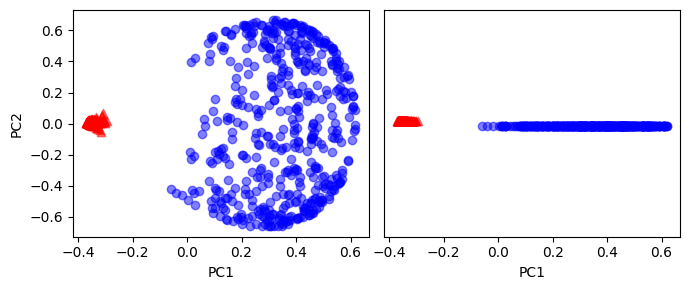

In [138]:
X_kpca = KernelPCA(n_components=2, gamma=10, kernel='rbf',)
X_spca = X_kpca.fit_transform(X)

fig, ax = plt.subplots(nrows=1, ncols=2,figsize=(7,3))

ax[0].scatter(X_spca[y==0, 0], X_spca[y==0, 1],
               color='red', marker='^', alpha=0.5)
ax[0].scatter(X_spca[y==1, 0], X_spca[y==1, 1],
               color='blue', marker='o', alpha=0.5)

ax[1].scatter(X_spca[y==0, 0], np.zeros((500,1))+0.02,
               color='red', marker='^', alpha=0.5)
ax[1].scatter(X_spca[y==1, 0], np.zeros((500,1))-0.02,
               color='blue', marker='o', alpha=0.5)

ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2')
ax[1].set_ylim([-1, 1])
ax[1].set_yticks([])
ax[1].set_xlabel('PC1')
plt.tight_layout()
plt.show()